# Análisis de Clustering y Silhouette con Visualización

Este notebook realiza un análisis profesional de clustering usando PySpark, calcula el índice de Silhouette.

## 1. Importar librerías necesarias

In [1]:
# Importar librerías
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql.types import NumericType
import os
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Inicializar SparkSession

In [2]:
# Inicializar SparkSession
spark = SparkSession.builder.appName('SilhouetteVisual').getOrCreate()

## 3. Cargar los datos desde la carpeta merge_pyspark

In [3]:
# Cargar todos los archivos Parquet de la carpeta merge_pyspark
parquet_folder = '../merge_pyspark'
parquet_files = [os.path.join(parquet_folder, f) for f in os.listdir(parquet_folder) if f.endswith('.parquet')]
df = spark.read.parquet(*parquet_files)
df.show(5)
df.printSchema()

+--------------------+----------+----------+------------------+----------------+------------+--------------------+---------------+-----------------+------------------+-----------------------+-------------------------+-----------------+-----------------+-------------------------+---------------------------+--------------------------+----------------------------+-------------+----------------+----------+----------------+--------------+----------------+----------+--------------------+----------------+------------------+--------------------+----+------+------------------+----------------------+---+--------------------+
|         customer_id|article_id|     Fecha|             price|sales_channel_id|product_code|           prod_name|product_type_no|product_type_name|product_group_name|graphical_appearance_no|graphical_appearance_name|colour_group_code|colour_group_name|perceived_colour_value_id|perceived_colour_value_name|perceived_colour_master_id|perceived_colour_master_name|department_no|

## 4. Preprocesamiento y conversión de fechas

In [ ]:
# Convertir la columna de fecha al formato adecuado y eliminar nulos
df = df.withColumn('fecha', to_date(col('fecha'), 'dd/MM/yyyy'))
df = df.dropna(subset=['fecha'])
df.select('fecha').show(5)

+----------+
|     fecha|
+----------+
|2019-11-28|
|2019-11-28|
|2019-02-10|
|2018-10-24|
|2019-02-10|
+----------+
only showing top 5 rows



## 5. División de los datos en dos conjuntos por rango de fechas

In [5]:
# Definir los rangos de fechas
from datetime import date
inicio_1 = date(2018, 9, 20)
fin_1 = date(2019, 12, 31)
inicio_2 = date(2020, 1, 1)
fin_2 = date(2020, 9, 22)

conjunto1 = df.filter((col('fecha') >= inicio_1) & (col('fecha') <= fin_1))
conjunto2 = df.filter((col('fecha') >= inicio_2) & (col('fecha') <= fin_2))
print('Conjunto 1:', conjunto1.count(), 'registros')
print('Conjunto 2:', conjunto2.count(), 'registros')

Conjunto 1: 20808192 registros
Conjunto 2: 10980132 registros


## 6. Selección automática de variables numéricas y vectorización

In [6]:
# Selección automática de columnas numéricas para clustering
columnas_numericas = [field.name for field in df.schema.fields if isinstance(field.dataType, NumericType) and field.name != 'fecha']
print('Columnas numéricas seleccionadas para clustering:', columnas_numericas)

conjunto1_clean = conjunto1.dropna(subset=columnas_numericas)
conjunto2_clean = conjunto2.dropna(subset=columnas_numericas)

assembler = VectorAssembler(inputCols=columnas_numericas, outputCol='features')

Columnas numéricas seleccionadas para clustering: ['article_id', 'price', 'sales_channel_id', 'product_code', 'product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'perceived_colour_master_id', 'department_no', 'index_group_no', 'section_no', 'garment_group_no', 'FN', 'Active', 'age']


## 7. Aplicar algoritmo de clustering (KMeans) y calcular Silhouette

In [7]:
# Vectorizar y ajustar KMeans
conjunto1_vec = assembler.transform(conjunto1_clean)
conjunto2_vec = assembler.transform(conjunto2_clean)

kmeans = KMeans(featuresCol='features', k=3, seed=42)
modelo1 = kmeans.fit(conjunto1_vec)
modelo2 = kmeans.fit(conjunto2_vec)

predicciones1 = modelo1.transform(conjunto1_vec)
predicciones2 = modelo2.transform(conjunto2_vec)

# Calcular el índice de Silhouette
silhouette_evaluator = ClusteringEvaluator(featuresCol='features', predictionCol='prediction', metricName='silhouette')
silhouette1 = silhouette_evaluator.evaluate(predicciones1)
silhouette2 = silhouette_evaluator.evaluate(predicciones2)
print(f'Índice de Silhouette para Conjunto 1: {silhouette1:.4f}')
print(f'Índice de Silhouette para Conjunto 2: {silhouette2:.4f}')

Índice de Silhouette para Conjunto 1: 0.7623
Índice de Silhouette para Conjunto 2: 0.7893


## 8. Visualización de clusters

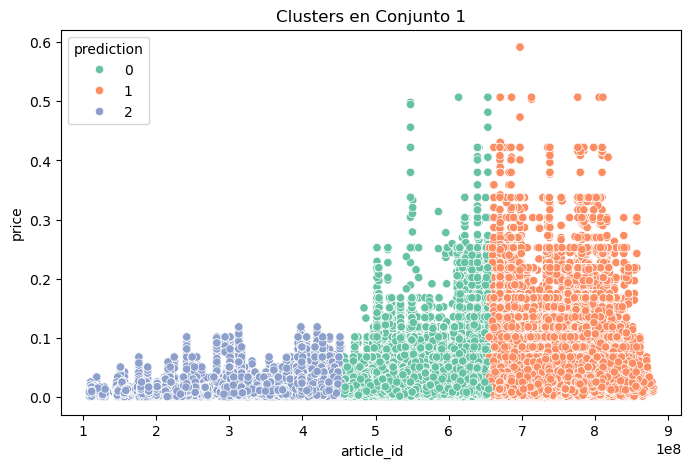

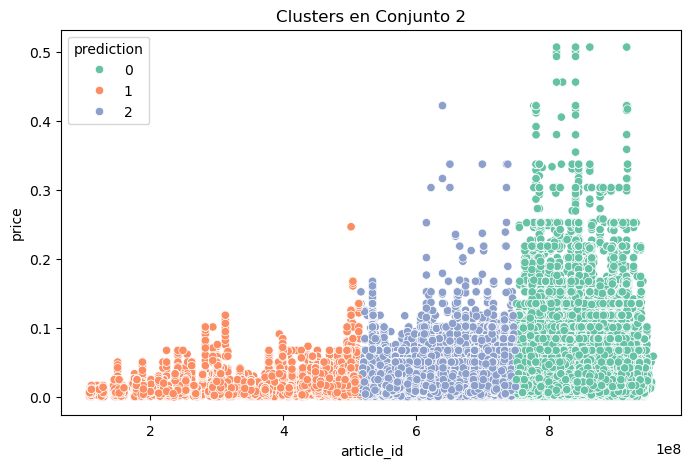

In [8]:
# Selecciona las dos primeras variables numéricas para graficar
var_x, var_y = columnas_numericas[:2]

# Graficar clusters para conjunto 1
pdf1 = predicciones1.select(var_x, var_y, 'prediction').toPandas()
plt.figure(figsize=(8,5))
sns.scatterplot(data=pdf1, x=var_x, y=var_y, hue='prediction', palette='Set2')
plt.title('Clusters en Conjunto 1')
plt.show()

# Graficar clusters para conjunto 2
pdf2 = predicciones2.select(var_x, var_y, 'prediction').toPandas()
plt.figure(figsize=(8,5))
sns.scatterplot(data=pdf2, x=var_x, y=var_y, hue='prediction', palette='Set2')
plt.title('Clusters en Conjunto 2')
plt.show()

## 9. Interpretación y recomendaciones

- Un índice de Silhouette cercano a 1 indica clusters bien definidos.
- Valores bajos sugieren solapamiento entre clusters.
